# **Data Visualization**


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-03-13 18:05:47--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  53.3MB/s    in 2.9s    

2026-03-13 18:05:50 (53.3 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [6]:
QUERY = """
SELECT COUNT(*)
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


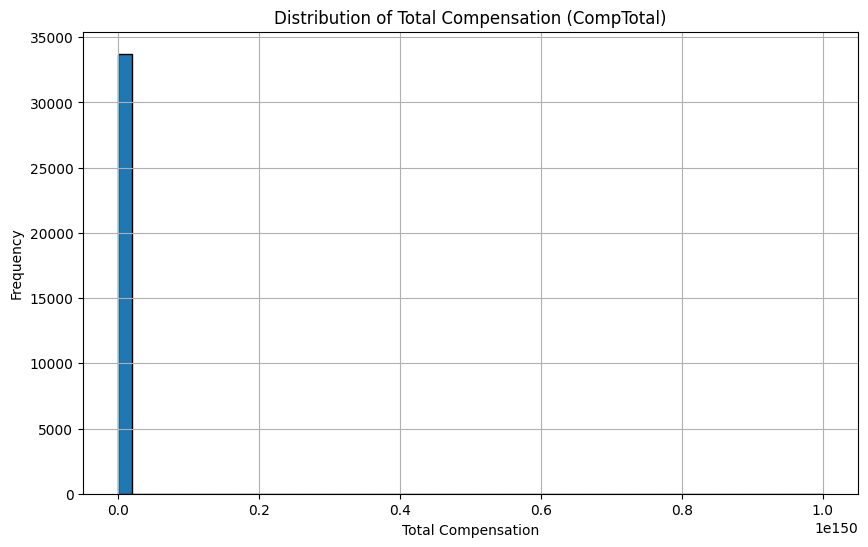

In [10]:
conn = sqlite3.connect('survey-data.sqlite')

QUERY = "SELECT CompTotal FROM main"
comptotal_df = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10, 6))
plt.hist(comptotal_df['CompTotal'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of Total Compensation (CompTotal)')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

conn.close()

**Box Plots**

Plot a box plot of Age.


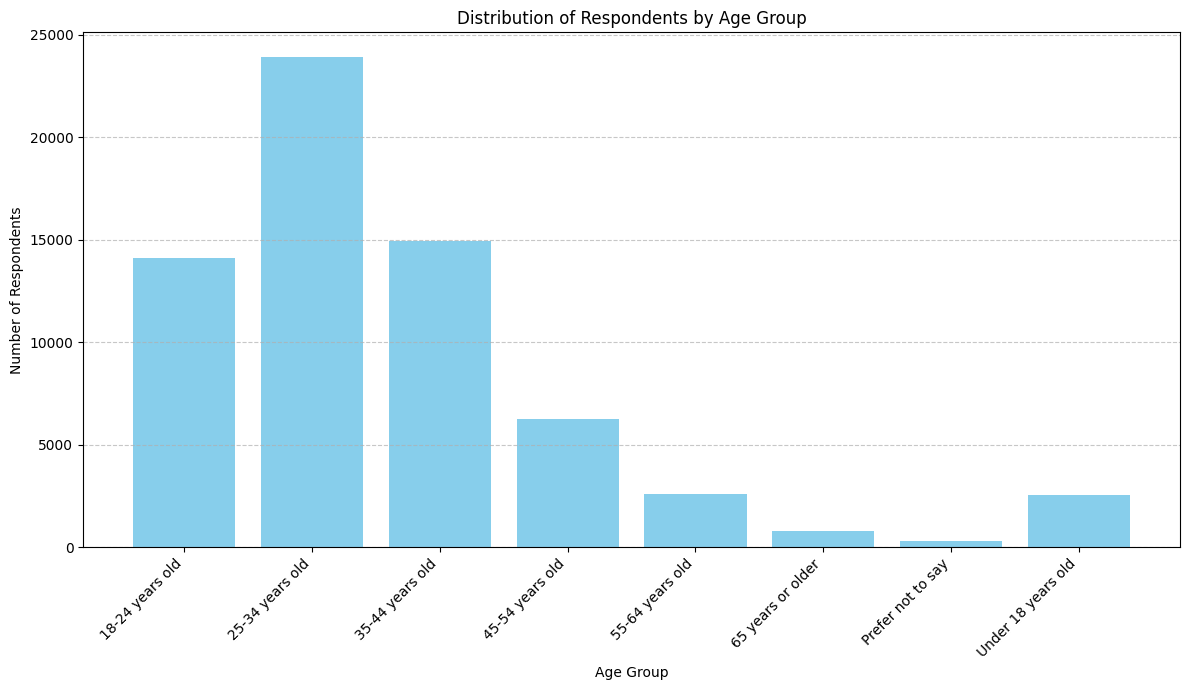

In [12]:
conn = sqlite3.connect('survey-data.sqlite')

QUERY = "SELECT Age, COUNT(*) as count FROM main GROUP BY Age ORDER BY Age"
age_counts_df = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(12, 7))
plt.bar(age_counts_df['Age'], age_counts_df['count'], color='skyblue')
plt.title('Distribution of Respondents by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

conn.close()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


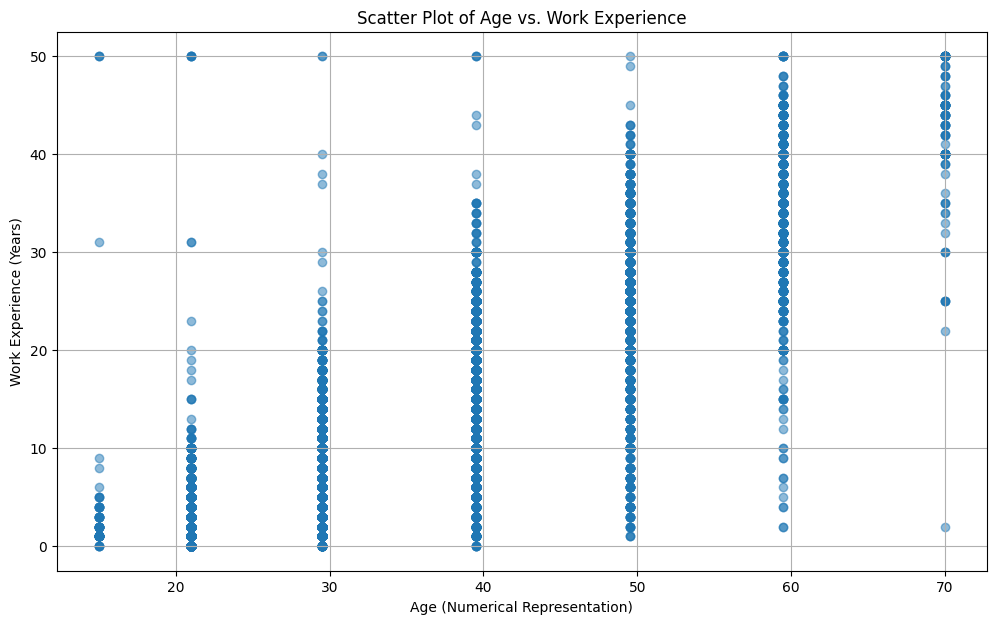

In [13]:
conn = sqlite3.connect('survey-data.sqlite')

QUERY = "SELECT Age, WorkExp FROM main WHERE Age IS NOT NULL AND WorkExp IS NOT NULL"
df_scatter = pd.read_sql_query(QUERY, conn)

# Map age categories to numerical values for plotting
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None # Will be dropped by dropna()
}
df_scatter['Age_Numerical'] = df_scatter['Age'].map(age_mapping)

# Drop rows where age could not be mapped (e.g., 'Prefer not to say')
df_scatter.dropna(subset=['Age_Numerical', 'WorkExp'], inplace=True)

plt.figure(figsize=(12, 7))
plt.scatter(df_scatter['Age_Numerical'], df_scatter['WorkExp'], alpha=0.5)
plt.title('Scatter Plot of Age vs. Work Experience')
plt.xlabel('Age (Numerical Representation)')
plt.ylabel('Work Experience (Years)')
plt.grid(True)
plt.show()

conn.close()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


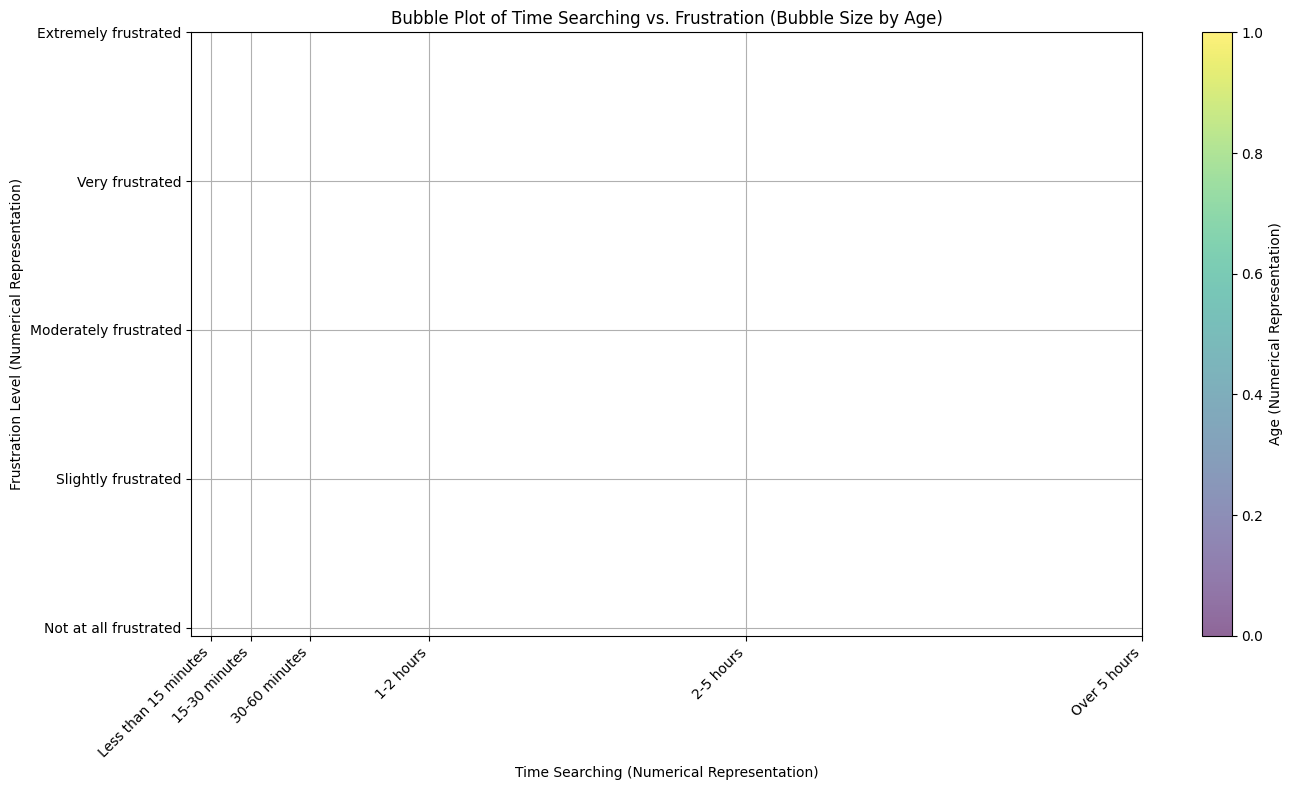

In [14]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# Query the necessary columns
QUERY = """
SELECT TimeSearching, Frustration, Age
FROM main
WHERE TimeSearching IS NOT NULL AND Frustration IS NOT NULL AND Age IS NOT NULL
"""
df_bubble = pd.read_sql_query(QUERY, conn)

# Define mappings for categorical columns to numerical values
# These mappings are based on common survey response patterns for time and frustration levels
time_searching_mapping = {
    'Less than 15 minutes': 7.5, # Midpoint in minutes
    '15-30 minutes': 22.5,
    '30-60 minutes': 45,
    '1-2 hours': 90, # 1.5 hours * 60 minutes
    '2-5 hours': 210, # 3.5 hours * 60 minutes
    'Over 5 hours': 360 # Arbitrary value for >5 hours (6 hours * 60 minutes)
}

frustration_mapping = {
    'Not at all frustrated': 0,
    'Slightly frustrated': 1,
    'Moderately frustrated': 2,
    'Very frustrated': 3,
    'Extremely frustrated': 4
}

# Age mapping for bubble size, similar to the previous scatter plot
age_mapping_for_size = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': np.nan # These rows will be dropped if 'Prefer not to say' is present
}

# Apply mappings to create numerical columns
df_bubble['TimeSearching_Numerical'] = df_bubble['TimeSearching'].map(time_searching_mapping)
df_bubble['Frustration_Numerical'] = df_bubble['Frustration'].map(frustration_mapping)
df_bubble['Age_Numerical_for_size'] = df_bubble['Age'].map(age_mapping_for_size)

# Drop rows where mapping resulted in NaN (i.e., categories not in mapping or original NaNs)
df_bubble.dropna(subset=['TimeSearching_Numerical', 'Frustration_Numerical', 'Age_Numerical_for_size'], inplace=True)

# Scale age for bubble size for better visual representation
# Adjust the scaling factor (e.g., 50) as needed to make bubbles discernible
df_bubble['Bubble_Size'] = df_bubble['Age_Numerical_for_size'] * 50

# Create the bubble plot
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    x=df_bubble['TimeSearching_Numerical'],
    y=df_bubble['Frustration_Numerical'],
    s=df_bubble['Bubble_Size'], # Size of bubbles based on scaled age
    alpha=0.6, # Transparency for better visibility of overlapping bubbles
    edgecolors='w', # White edges for better distinction between bubbles
    c=df_bubble['Age_Numerical_for_size'], # Color bubbles by age for additional insight
    cmap='viridis' # Colormap for age
)

plt.title('Bubble Plot of Time Searching vs. Frustration (Bubble Size by Age)')
plt.xlabel('Time Searching (Numerical Representation)')
plt.ylabel('Frustration Level (Numerical Representation)')

# Create a colorbar for Age_Numerical_for_size to explain bubble colors
cbar = plt.colorbar(scatter)
cbar.set_label('Age (Numerical Representation)')

# Set custom x-axis tick labels to show original categorical descriptions
x_tick_values = sorted(time_searching_mapping.values())
x_tick_labels_ordered = [k for v in x_tick_values for k, val in time_searching_mapping.items() if val == v]
plt.xticks(x_tick_values, x_tick_labels_ordered, rotation=45, ha='right')

# Set custom y-axis tick labels to show original categorical descriptions
y_tick_values = sorted(frustration_mapping.values())
y_tick_labels_ordered = [k for v in y_tick_values for k, val in frustration_mapping.items() if val == v]
plt.yticks(y_tick_values, y_tick_labels_ordered)

plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Close the database connection
conn.close()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


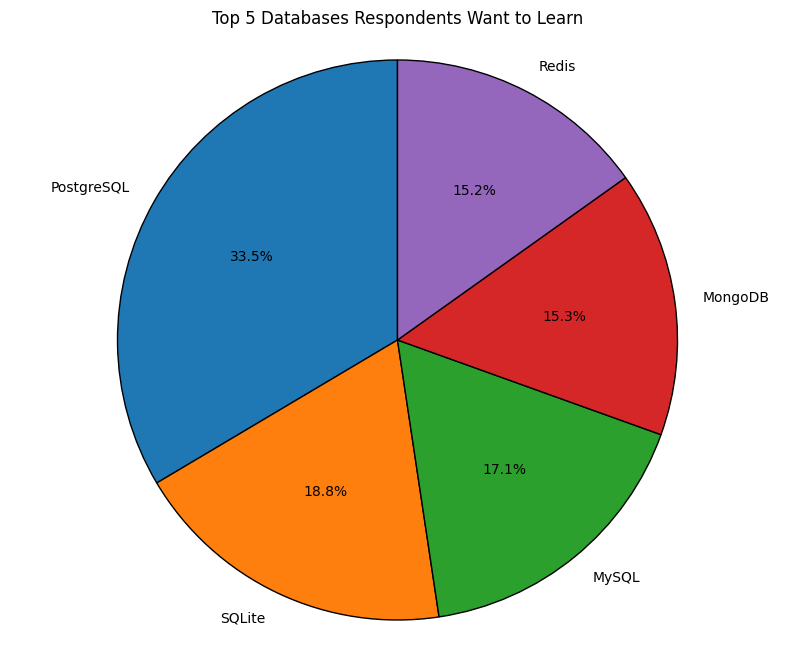

In [15]:
conn = sqlite3.connect('survey-data.sqlite')

QUERY = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
db_want_df = pd.read_sql_query(QUERY, conn)

# Split the string of databases and count each one
db_counts = {}
for index, row in db_want_df.iterrows():
    databases = row['DatabaseWantToWorkWith'].split(';')
    for db in databases:
        db = db.strip()
        db_counts[db] = db_counts.get(db, 0) + 1

# Convert to a Series and get the top 5
db_counts_series = pd.Series(db_counts).sort_values(ascending=False)
top_5_db = db_counts_series.head(5)

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(top_5_db, labels=top_5_db.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Top 5 Databases Respondents Want to Learn')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

conn.close()

**Stacked Charts**

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


In [17]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# Query the necessary columns, filtering for the age group '25-34 years old'
# This is the closest group to '30 to 35' in the dataset.
QUERY = """
SELECT TimeSearching, TimeAnswering, Age
FROM main
WHERE Age = '25-34 years old' AND TimeSearching IS NOT NULL AND TimeAnswering IS NOT NULL
"""
df_stacked = pd.read_sql_query(QUERY, conn)

# Define mappings for categorical time columns to numerical values (midpoints)
time_mapping = {
    'Less than 15 minutes': 7.5,
    '15-30 minutes': 22.5,
    '30-60 minutes': 45,
    '1-2 hours': 90,
    '2-5 hours': 210,
    'Over 5 hours': 360
}

# Apply mappings to create numerical columns
df_stacked['TimeSearching_Numerical'] = df_stacked['TimeSearching'].map(time_mapping)
df_stacked['TimeAnswering_Numerical'] = df_stacked['TimeAnswering'].map(time_mapping)

# Drop rows where mapping resulted in NaN
df_stacked.dropna(subset=['TimeSearching_Numerical', 'TimeAnswering_Numerical'], inplace=True)

# Check if the DataFrame is empty after filtering and mapping
if df_stacked.empty:
    print(f"No valid data found for Age group '25-34 years old' with non-null and mappable TimeSearching and TimeAnswering values.")
else:
    # Calculate median for TimeSearching and TimeAnswering
    median_time_searching = df_stacked['TimeSearching_Numerical'].median()
    median_time_answering = df_stacked['TimeAnswering_Numerical'].median()

    # Create a DataFrame for plotting
    plot_data = pd.DataFrame({
        'Category': ['25-34 years old'],
        'Time Searching': [median_time_searching],
        'Time Answering': [median_time_answering]
    })

    # Create the stacked bar chart
    plot_data.plot(x='Category', kind='bar', stacked=True, figsize=(8, 6), colormap='viridis')
    plt.title('Median Time Searching and Time Answering for Age Group 25-34 years old')
    plt.xlabel('Age Group')
    plt.ylabel('Median Time (minutes)')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Close the database connection
conn.close()

No valid data found for Age group '25-34 years old' with non-null and mappable TimeSearching and TimeAnswering values.


### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


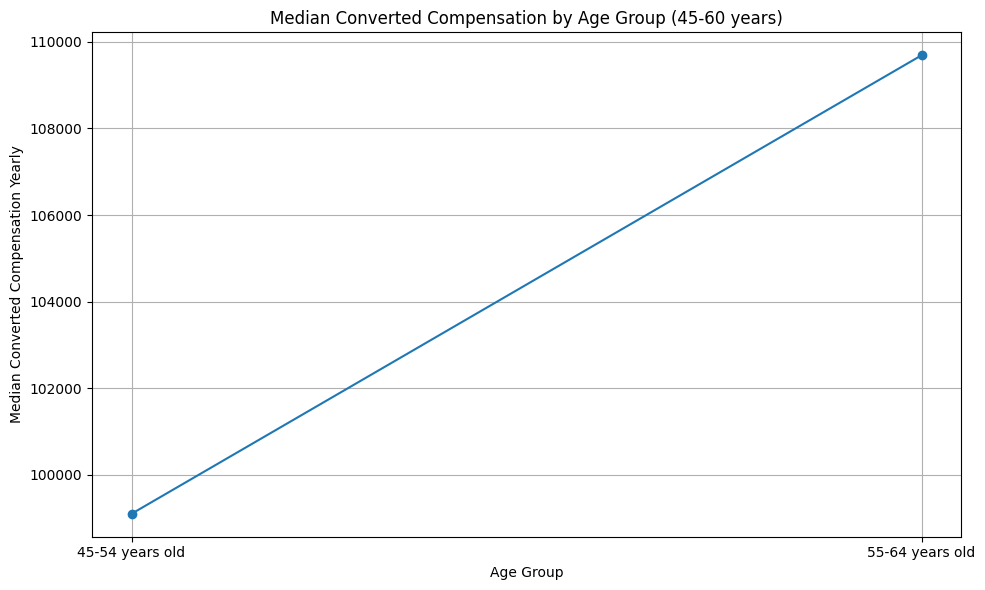

In [18]:
conn = sqlite3.connect('survey-data.sqlite')

QUERY = """
SELECT Age, ConvertedCompYearly
FROM main
WHERE Age IN ('45-54 years old', '55-64 years old') AND ConvertedCompYearly IS NOT NULL
"""
df_line = pd.read_sql_query(QUERY, conn)

# Map age categories to numerical values for plotting, if desired for the X-axis
age_mapping_for_line = {
    '45-54 years old': 49.5,
    '55-64 years old': 59.5
}
df_line['Age_Numerical'] = df_line['Age'].map(age_mapping_for_line)

# Calculate median ConvertedCompYearly for each age group
median_comp_by_age = df_line.groupby('Age', sort=False)['ConvertedCompYearly'].median().reset_index()

# Ensure the numerical age is also included for sorting/plotting if needed
median_comp_by_age['Age_Numerical'] = median_comp_by_age['Age'].map(age_mapping_for_line)
median_comp_by_age = median_comp_by_age.sort_values(by='Age_Numerical')

plt.figure(figsize=(10, 6))
plt.plot(median_comp_by_age['Age'], median_comp_by_age['ConvertedCompYearly'], marker='o', linestyle='-')
plt.title('Median Converted Compensation by Age Group (45-60 years)')
plt.xlabel('Age Group')
plt.ylabel('Median Converted Compensation Yearly')
plt.grid(True)
plt.tight_layout()
plt.show()

conn.close()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


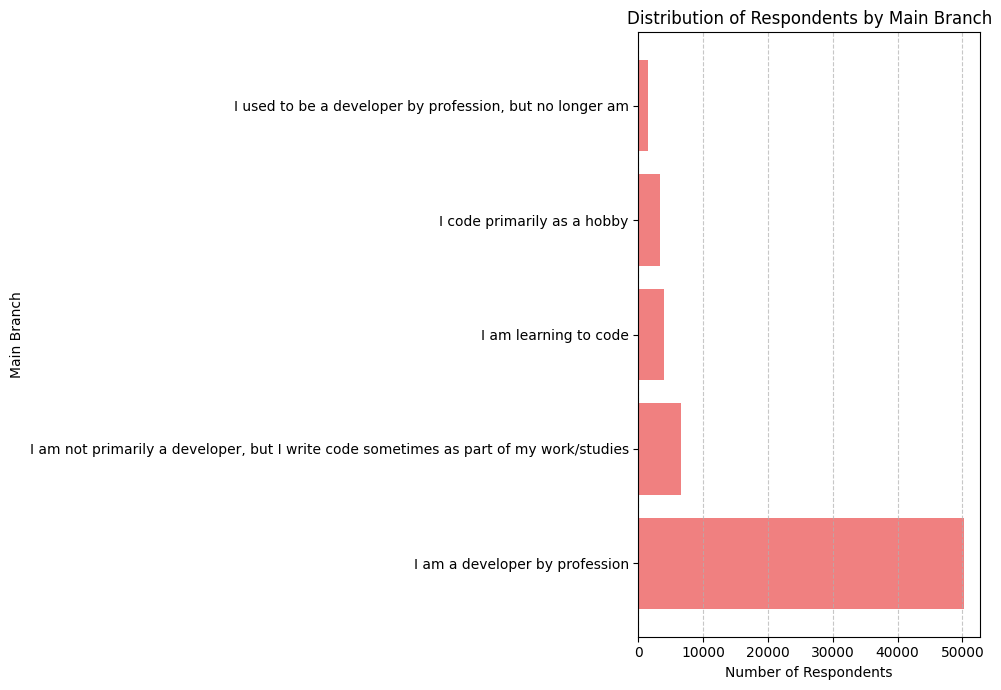

In [19]:
conn = sqlite3.connect('survey-data.sqlite')

QUERY = "SELECT MainBranch, COUNT(*) as count FROM main GROUP BY MainBranch ORDER BY count DESC"
mainbranch_counts_df = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10, 7))
plt.barh(mainbranch_counts_df['MainBranch'], mainbranch_counts_df['count'], color='lightcoral')
plt.xlabel('Number of Respondents')
plt.ylabel('Main Branch')
plt.title('Distribution of Respondents by Main Branch')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

conn.close()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [20]:
conn.close()

## Authors:
Sumant Chakravarty
